Basic Chatbot

In [3]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="qwen/qwen3-32b")

In [7]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

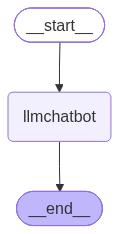

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response=graph.invoke({"messages":"Hi"})

NotFoundError: Error code: 404 - {'error': {'message': 'The model `qwen/qwen3-32b` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [19]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond politely. Let me make sure I acknowledge their greeting and offer assistance. Maybe say something like "Hello! How can I help you today?" That\'s friendly and opens the door for them to ask questions. I need to keep it simple and welcoming. No need for any complex language here. Just a straightforward, positive response.\n</think>\n\nHello! How can I help you today? 😊'

In [20]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user asked "Hi How are you?" which is a greeting. I should respond in a friendly and welcoming manner. I'll acknowledge their greeting and offer assistance. It's important to keep the response natural and conversational. I need to make sure it's clear that I'm here to help with any questions or tasks they might have. Also, since I'm an AI, I should mention that I don't experience feelings like humans do, but I'm ready to work with them. I'll keep the tone positive and open-ended.
</think>

Hello! I'm an AI assistant, so I don't experience feelings in the way humans do, but I'm here and ready to help! How can I assist you today? 😊


In [1]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [2]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [3]:
tools=[tool,multiply]

In [7]:
llm_with_tool=llm.bind_tools(tools)

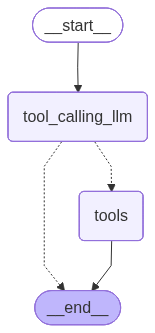

In [10]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [11]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [12]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "The Latest AI News and Breakthroughs That Matter Most", "content": "Source:WION News\\n\\n### (AI News) Battery Breakthroughs Will Lessen AI\'s Demand on the Electricity Grid\\n\\nDate: June 12, 2026\\n\\nSummary: The Washington Post editorial board argues that battery innovations will ease AI\'s strain on electricity grids. Recent advances include General Motors\' vehicle-to-grid technology, which transforms hundreds of thousands of battery-powered cars into distributed power plants. A shift from lithium to sodium-ion batteries will reduce reliance on Chinese supply chains while maintaining performance. These innovations create virtual power networks that balance grid demand and address the electricity crisis created by AI data center expansion. Battery breakthroughs offer hope for sustaining both AI growth an

In [13]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (4m02b2hbp)
 Call ID: 4m02b2hbp
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "The Latest AI News and Breakthroughs That Matter Most", "content": "Source:WION News\n\n### (AI News) Battery Breakthroughs Will Lessen AI's Demand on the Electricity Grid\n\nDate: June 12, 2026\n\nSummary: The Washington Post editorial board argues that battery innovations will ease AI's strain on electricity grids. Recent advances include General Motors' vehicle-to-

In [14]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (r16bexwge)
 Call ID: r16bexwge
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [15]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (pmkhengak)
 Call ID: pmkhengak
  Args:
    query: recent AI news
    time_range: week
  multiply (je0ammjfd)
 Call ID: je0ammjfd
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "title": "The Latest AI News and Breakthroughs That Matter Most", "content": "Source:WION News\n\n### (AI News) Battery Breakthroughs Will Lessen AI's Demand on the Electricity Grid\n\nDate: June 12, 2026\n\nSummary: The Washington Post editorial board argues that battery innovations will ease AI's strain on electricity grids. R

### ReAct Agent Architecture

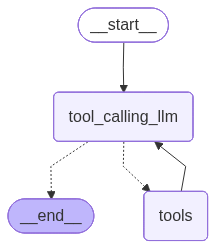

In [16]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bdv2abhcy)
 Call ID: bdv2abhcy
  Args:
    query: AI news
    time_range: week
    topic: news
  multiply (hajndqarw)
 Call ID: hajndqarw
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/07/10/ais-next-race-cost-control-and-compute.html", "title": "AI’s Next Race: Cost, Control, and Compute - CNBC", "score": 0.6543875, "published_date": "Fri, 10 Jul 2026 21:26:48 GMT", "content": "# AI’s Next Race: Cost, Control, and Compute. Perplexity CEO Aravind Srinivas joins to discuss the company’s new orchestrator model, why he’s building on open

### Adding Memory In Agentic Graph

In [18]:
response=graph.invoke({"messages":"Hello my name is KRish"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Hello KRish! How can I assist you today?


In [19]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to personal information about users unless it's explicitly provided in the conversation. Would you like to tell me your name?


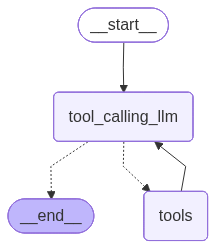

In [20]:

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Krish"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Krish', additional_kwargs={}, response_metadata={}, id='e31068aa-d6eb-490a-bd4a-41943da15023'),
  AIMessage(content='Hello Krish! How can I assist you today? If you have any questions or need help with something, feel free to ask. 😊', additional_kwargs={'reasoning_content': 'Okay, the user said, "Hi my name is Krish." Let me think about how to respond.\n\nFirst, I need to acknowledge their greeting. A simple "Hello" seems appropriate. Then, I should mention their name to make it personal. Maybe add an offer to help with any questions they might have. \n\nLooking at the tools provided, there\'s a search function and a multiply function. But the user didn\'t ask anything that requires using those tools yet. They just introduced themselves. So, no need to call any functions here. Just a friendly response to start the conversation.\n'}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 1786, 'total_tokens': 1937,

In [22]:
response['messages'][-1].content

'Hello Krish! How can I assist you today? If you have any questions or need help with something, feel free to ask. 😊'

In [23]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Hello again! Your name is Krish. 😊 Let me know if there's anything I can assist you with!


In [25]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

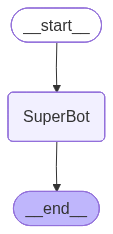

In [26]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [27]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='29ae20eb-43c0-4341-bb83-74027835816d'),
  AIMessage(content='<think>\nOkay, let\'s see. The user introduced themselves as Krish and mentioned liking cricket. So, first, I need to respond warmly to their greeting. Maybe start with a friendly "Hi Krish!" to acknowledge their name. Then, comment on their interest in cricket. Since cricket is a popular sport, I can say something like "Great choice! I know it\'s a sport you\'re passionate about." That shows I recognize their interest.\n\nNext, I should offer to help or engage further. Maybe ask if they want to discuss cricket, like strategies, players, or updates on the game. But wait, the user hasn\'t asked a question or requested anything specific. They just provided information. So maybe I should ask an open-ended question to encourage conversation. For example, "Are you a fan of any particular team or player?" or 

### Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [28]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, the user introduced himself as Krish and mentioned he likes cricket. So, I need to respond in a friendly and engaging way. Let me think about how to acknowledge both his name and his interest.\n\nFirst, a simple greeting to welcome him. Then, maybe ask a follow-up question about cricket to keep the conversation going. I should make sure the response is warm and shows genuine interest. Maybe something like, "Hi Krish! Nice to meet you. Cricket is an amazing sport—do you play it, or are you more of a fan? I\'d love to hear more about what you enjoy about it!" That way, I\'m acknowledging his name, his interest, and opening the door for him to elaborate. Let me check if that\'s clear and friendly. Yeah, sounds good. I\'ll go with that.\n</think>\n\nHi Krish! Nice to meet you. 🏏 Cricket is an amazing sport—do you play it, or are you more of a fan? I\'d love to hear more about what you enjoy about it!', additional_kwargs={}, respo